# 풍력터빈 블레이드 오염·손상 자동 탐지 — 4조 빙글빙글 최종 정리본

드론이 찍은 풍력터빈 블레이드 사진에서 **오염(dirt)과 손상(damage)을 자동으로 찾는 객체탐지(Object Detection)** 프로젝트다.
블레이드 점검은 고공 작업이라 현장은 드론으로 찍는데, 찍힌 사진 확인은 아직 사람 눈이다. 그 다음 단계(자동 탐지)가 우리 과제였다.

- **데이터**: 캐글 공개 데이터셋 [YOLO Annotated Wind Turbine Surface Damage](https://www.kaggle.com/datasets/ajifoster3/yolo-annotated-wind-turbines-586x371) — 덴마크공대(DTU)의 NordTank 터빈을 드론으로 실측 촬영한 13,470장 (586x371)
- **방식**: COCO 사전학습 YOLO를 이 데이터로 파인튜닝
- **팀 (4조 빙글빙글)**: 김민 · 김민욱 · 박정우 · 이예령 · 최병철

| 이름 | 맡은 갈래 |
|---|---|
| 박정우 (팀장) | baseline 재현 · v8+v12 2모델 앙상블 선공 ("돋보기+현미경") |
| 김민욱 (발표) | 5모델 오디션 · 정상 이미지 주입 · 5모델 WBF 앙상블 · rtdetr 환경 규명 |
| 김민 | 변형 baseline · 대규모 증강 재학습 · 6모델 백테스트 · 영상 탐지 데모 |
| 이예령 | 외부 고해상도 데이터 발굴 · 타일화 · SAHI 슬라이싱 |
| 최병철 | 외부 데이터셋 발굴 · 검사기술 리서치(AS-IS/TO-BE) · 웹서비스 배포 |

**이 노트북 하나로** [데이터 준비 -> EDA -> 5모델 비교 -> 개선 실험(정상 주입 / WBF 앙상블) -> 외부 데이터 검증 -> 회고]를 따라올 수 있게 정리했다.

읽기 전에 두 가지:
1. 50에폭 학습과 앙상블 추론은 GPU로 오래 걸려서, 아래 "실행 설정"의 스위치(`RUN_*`)를 켰을 때만 돌게 했다. **수치·그림은 전부 실제 실험값**을 그대로 실었다.
2. 우리 숫자에는 잣대가 두 개다 — **잣대A = 공식 채점기(`model.val()`)**, **잣대B = 자체 채점기(conf 0.05, 앙상블 비교용)**. 표마다 어느 잣대인지 적어뒀고, 잣대가 다른 숫자끼리는 직접 잇지 않았다(6장에서 자세히).

팀원별 상세 기록은 `team/` 폴더, 실험 리포트 전문은 `results_summary/` 폴더, 실행 스크립트 원본은 `code/` 폴더에 있다.  
폴더 전체에서 무엇을 먼저 볼지 순서 안내는 [MQ02_리뷰가이드.md](MQ02_리뷰가이드.md)에 적어뒀다.

# 1. 설치

아래 셀은 최초 1회만 실행하면 된다. 이미 설치돼 있으면 조용히 넘어간다.

In [1]:
# 최초 1회만 실행
%pip install -q ultralytics ensemble-boxes

Note: you may need to restart the kernel to use updated packages.


# 2. 실행 설정

무거운 단계는 스위치로 보호했다. 재현하려면 True로 바꾸면 된다.

In [2]:
# 무거운 단계 스위치 — 기본은 꺼둠 (결과는 실제 실험값을 아래 표·그림으로 수록)
RUN_SPLIT    = False   # 데이터 split 재생성 (라벨 있는 2,995장 복사, 수 초)
RUN_TRAINING = False   # 50에폭 학습 (GPU 기준 모델당 30분~수 시간, 5모델이면 그 5배)
RUN_ENSEMBLE = False   # 5모델 WBF 앙상블 추론+채점 (test 301장 x 5모델, CPU 수십 분)

# 데이터 위치 — 내 환경에 맞게 바꾼다
DATA_SRC  = "/home/gmw/Documents/AIFFEL_Work/_scratch/Main_Quest/MQ02/data/NordTank586x371"
#  캐글: "/kaggle/input/yolo-annotated-wind-turbines-586x371/NordTank586x371"
#  코랩: "/content/NordTank586x371"
SPLIT_DIR = "/home/gmw/Documents/AIFFEL_Work/_scratch/Main_Quest/MQ02/data/split"   # split 결과 위치

# 학습 설정 — 팀 전원 동일 (같아야 모델끼리 비교가 공정하다)
EPOCHS, IMGSZ, BATCH, SEED = 50, 640, 16, 42

# 3. 라이브러리 로드

In [3]:
import os, glob, random, shutil
from collections import defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Rectangle
from PIL import Image

# 한글 폰트 (그래프 라벨용)
for fp in ["/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
           "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"]:
    if os.path.exists(fp):
        font_manager.fontManager.addfont(fp)
        matplotlib.rcParams["font.family"] = font_manager.FontProperties(fname=fp).get_name()
        break
matplotlib.rcParams["axes.unicode_minus"] = False
print("준비 완료")

준비 완료


# 4. 데이터를 뜯어보니 (EDA)

기본 제공 흐름은 "라벨 있는 이미지만" 쓴다. 정말 그래도 되는지, 데이터 구성부터 직접 세어봤다.
(라벨 폴더의 `labels.txt`는 클래스 이름 파일이라 어노테이션이 아니다 — 세기 전에 제외)

In [4]:
# 4.1 전체 구성 — 이미지가 몇 장이고, 라벨(정답 박스)이 있는 건 몇 장인가
img_files = glob.glob(os.path.join(DATA_SRC, "images", "*.png"))
lbl_files = [f for f in glob.glob(os.path.join(DATA_SRC, "labels", "*.txt"))
             if os.path.basename(f) != "labels.txt"]   # labels.txt = 클래스 이름 파일이라 제외

n_total   = len(img_files)
n_labeled = len(lbl_files)
n_normal  = n_total - n_labeled
print(f"전체 이미지      : {n_total:,}장")
print(f"라벨 있는 이미지 : {n_labeled:,}장")
print(f"정상(라벨 없음)  : {n_normal:,}장 = 전체의 {n_normal/n_total*100:.0f}%")

전체 이미지      : 13,470장
라벨 있는 이미지 : 2,995장
정상(라벨 없음)  : 10,475장 = 전체의 78%


In [5]:
# 4.2 클래스별 박스 수와 크기 — dirt(0)와 damage(1)는 얼마나 다르게 생겼나
box_count = defaultdict(int)
box_area  = defaultdict(list)    # 클래스별 박스 넓이 (화면 대비 비율)
for lf in lbl_files:
    for line in open(lf):
        v = line.split()
        if len(v) != 5:
            continue
        c = int(v[0])
        box_count[c] += 1
        box_area[c].append(float(v[3]) * float(v[4]))   # (정규화 폭 x 높이) = 화면 대비 넓이

print(f"dirt 박스   : {box_count[0]:,}개, 크기 중앙값 = 화면의 {np.median(box_area[0])*100:.1f}%")
print(f"damage 박스 : {box_count[1]:,}개, 크기 중앙값 = 화면의 {np.median(box_area[1])*100:.2f}%")
print(f"개수 비율   : dirt 1 : damage {box_count[1]/box_count[0]:.0f}")

dirt 박스   : 581개, 크기 중앙값 = 화면의 32.4%
damage 박스 : 8,770개, 크기 중앙값 = 화면의 0.15%
개수 비율   : dirt 1 : damage 15


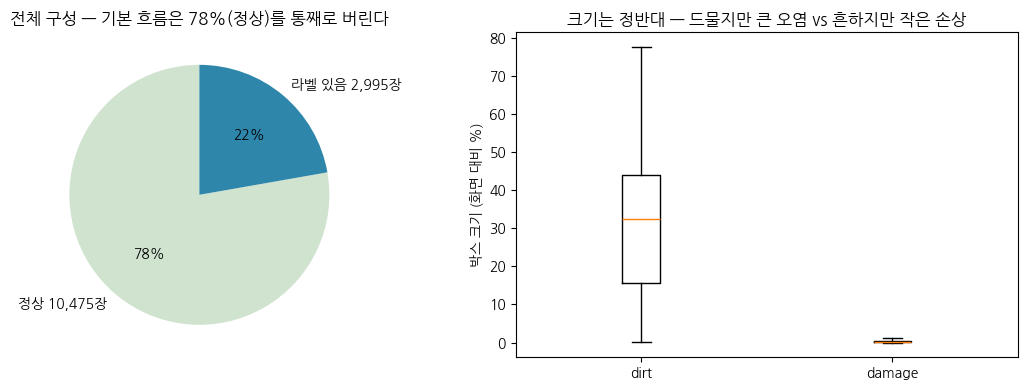

In [6]:
# 4.3 그림으로 — 구성 파이 + 클래스별 크기 분포
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.pie([n_normal, n_labeled], labels=[f"정상 {n_normal:,}장", f"라벨 있음 {n_labeled:,}장"],
        autopct="%1.0f%%", colors=["#cfe3cf", "#2e86ab"], startangle=90)
ax1.set_title("전체 구성 — 기본 흐름은 78%(정상)를 통째로 버린다")

ax2.boxplot([np.array(box_area[0])*100, np.array(box_area[1])*100],
            tick_labels=["dirt", "damage"], showfliers=False)
ax2.set_ylabel("박스 크기 (화면 대비 %)")
ax2.set_title("크기는 정반대 — 드물지만 큰 오염 vs 흔하지만 작은 손상")
plt.tight_layout(); plt.show()

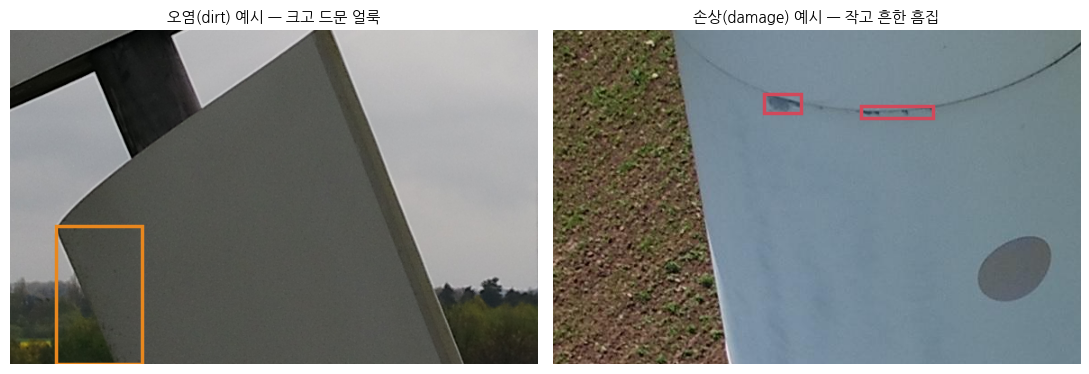

In [7]:
# 4.4 실제로 어떻게 생겼나 — 정답 박스를 눈으로 확인
samples = [("DJI_0584_05_05", "오염(dirt) 예시 — 크고 드문 얼룩"),
           ("DJI_0216_02_04", "손상(damage) 예시 — 작고 흔한 흠집")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (stem, title) in zip(axes, samples):
    img = Image.open(os.path.join(SPLIT_DIR, "test", "images", stem + ".png"))
    W, H = img.size
    ax.imshow(img)
    for line in open(os.path.join(SPLIT_DIR, "test", "labels", stem + ".txt")):
        c, cx, cy, w, h = line.split()
        cx, cy, w, h = float(cx)*W, float(cy)*H, float(w)*W, float(h)*H
        col = "#e8871e" if int(c) == 0 else "#d1495b"
        ax.add_patch(Rectangle((cx-w/2, cy-h/2), w, h, fill=False, edgecolor=col, linewidth=2.5))
    ax.set_title(title, fontsize=11); ax.axis("off")
plt.tight_layout(); plt.show()

### EDA 요약 — 네 가지 발견

1. 전체 13,470장 중 라벨 있는 건 2,995장뿐. **정상 10,475장(78%)을 기본 흐름은 통째로 버린다.** 모델이 "정상"을 배운 적이 없으니 깨끗한 곳도 손상으로 볼 수 있다 -> 개선 1(정상 주입)의 출발점.
2. 박스 수는 **dirt : damage = 1 : 15**. 오염이 아주 드물다 -> 평가는 mAP 하나 말고 **클래스별 AP**를 꼭 봐야 한다.
3. 크기는 정반대: **dirt 중앙값 = 화면의 32%** (초대형 얼룩) vs **damage 중앙값 = 0.15%** (약 18픽셀 바늘). 드물지만 큰 오염, 흔하지만 작은 손상 — 이 특징이 뒤에서 계속 중요해진다.
4. 이미지 크기는 586x371로 균일. 학습 입력(imgsz)은 640으로 통일했다.

# 5. 공정 비교의 틀 — train/val/test 분할

- 라벨 있는 2,995장을 **80/10/10**으로 분할: train 2,395 / val 299 / **test 301**.
- dirt가 1:15로 희귀해서 무작위로 자르면 한쪽에 쏠려 평가가 운에 휘둘린다 -> **dirt 포함 여부로 층화(stratify)** 분할.
- **test 301장은 "금고에 넣은 수능 시험지"**: 이후 모든 실험(5모델 비교, 정상 주입, 앙상블)이 같은 301장으로 채점됐고, 바뀌는 건 학습 재료뿐이다. 시험지가 같아야 점수 차이 = 실력 차이가 성립한다.
- 학습 설정도 전원 동일: 50에폭 / imgsz 640 / batch 16 / seed 42.

In [8]:
# 팀 공통 코드(code/MQ02_baseline.py)의 split 함수 그대로
def prepare_split(src, out):
    """데이터를 train/val/test로 나눠 split 폴더 + data.yaml 생성.
       Dirt가 희귀(1:15)해서 'Dirt 포함 여부'로 층화 분할한다. seed 고정 -> 누가 돌려도 동일."""
    img_dir, lbl_dir = os.path.join(src, "images"), os.path.join(src, "labels")
    label_files = sorted(f for f in glob.glob(os.path.join(lbl_dir, "*.txt"))
                         if os.path.basename(f) != "labels.txt")
    items = []
    for lf in label_files:
        base = os.path.splitext(os.path.basename(lf))[0]
        img = os.path.join(img_dir, base + ".png")
        if not os.path.exists(img):
            continue
        has_dirt = any(line.strip().startswith("0 ") for line in open(lf))
        items.append((base, img, lf, has_dirt))

    def split_group(group):
        g = sorted(group, key=lambda x: x[0]); random.Random(SEED).shuffle(g)
        n = len(g); a = int(n*0.8); b = int(n*0.1)
        return g[:a], g[a:a+b], g[a+b:]

    dirt   = [it for it in items if it[3]]
    nodirt = [it for it in items if not it[3]]
    d = split_group(dirt); nd = split_group(nodirt)
    splits = {"train": d[0]+nd[0], "val": d[1]+nd[1], "test": d[2]+nd[2]}

    if os.path.exists(out): shutil.rmtree(out)
    for sp, rows in splits.items():
        os.makedirs(os.path.join(out, sp, "images"), exist_ok=True)
        os.makedirs(os.path.join(out, sp, "labels"), exist_ok=True)
        for base, img, lbl, _ in rows:
            shutil.copy2(img, os.path.join(out, sp, "images", base+".png"))
            shutil.copy2(lbl, os.path.join(out, sp, "labels", base+".txt"))
    with open(os.path.join(out, "data.yaml"), "w") as f:
        f.write(f"path: {os.path.abspath(out)}\n")
        f.write("train: train/images\nval: val/images\ntest: test/images\n")
        f.write("nc: 2\nnames:\n  0: dirt\n  1: damage\n")


if RUN_SPLIT:
    prepare_split(DATA_SRC, SPLIT_DIR)

# 지금 디스크에 있는 split 구성을 실제로 세어 확인 (층화가 잘 됐는지 dirt 비율까지)
for sp in ("train", "val", "test"):
    lbls = glob.glob(os.path.join(SPLIT_DIR, sp, "labels", "*.txt"))
    with_dirt = sum(1 for lf in lbls
                    if any(l.strip().startswith("0 ") for l in open(lf)))
    print(f"{sp:5} : {len(lbls):5,}장 (dirt 포함 {with_dirt}장, {with_dirt/len(lbls)*100:.0f}%)")

train : 2,395장 (dirt 포함 450장, 19%)
val   :   299장 (dirt 포함 56장, 19%)
test  :   301장 (dirt 포함 57장, 19%)


# 6. 성적표 읽는 법 — 지표 개념 (여기만 이해하면 아래 숫자가 다 읽힌다)

### IoU = 박스가 맞았는지 재는 자
탐지는 박스가 "애매하게 맞을" 수 있어서, 정답 박스와 예측 박스의 **겹침 비율(IoU = 교집합/합집합)**로 판정한다. IoU가 기준선(보통 0.5)을 넘으면 맞은 탐지(TP)로 인정.

### precision / recall = 실수의 두 종류
- precision = 내가 "손상"이라 외친 것 중 진짜 비율 -> **헛것을 안 보는 능력**
- recall = 실제 손상 중 내가 찾아낸 비율 -> **안 놓치는 능력**
- 풍력터빈 점검은 "놓치면 큰일"이라 우리는 **recall(특히 damage recall)을 우선**했다.

### mAP50 vs mAP50-95 = 채점 "자의 개수" 차이
- **mAP50** = IoU 자를 0.5 하나만 씀. 박스가 좀 헐렁해도 찾으면 인정 -> "손상을 **찾았나**"
- **mAP50-95** = 자를 0.50~0.95까지 10개 들이대 10번 채점해 평균 -> "박스를 **칼같이 그렸나**"
- 예: 정답과 IoU 0.72로 겹친 박스 -> mAP50에선 만점, mAP50-95에선 자 10개 중 5개만 통과라 반쪽 점수.

![mAP 자 개념](../images/map_rulers_concept.png)

### ★ 잣대 두 개 (우리 숫자 읽기의 최대 함정)
- **잣대A = 공식 채점기 `model.val()`**: baseline·정상주입 숫자들. 절대값으로 유효.
- **잣대B = 자체 채점기(conf 0.05)**: 앙상블은 "모델"이 아니라 "박스 목록"이라 `model.val()`에 넣을 주체가 없다. 그래서 박스 목록끼리 GT와 대조하는 채점기를 직접 만들었고, 단일 모델들도 **같은 채점기로 다시 재서** 비교했다. 상대비교로만 유효.
- 금지 문장: "recall이 0.72에서 0.94로 올랐다" (잣대가 다른 두 숫자). 맞는 문장: "같은 자체 채점기 기준, 단일 최고 0.856 -> 앙상블 0.944".

# 7. 1차전 — 5모델 오디션 (각자 부딪히기)

후보를 하나만 찍지 않고 오디션을 열었다: YOLO 4세대(v8s/11s/v10s/12s) + 계열이 다른 트랜스포머 기반 rtdetr-l.
전부 s 체급, 같은 설정(50ep/640/16/seed42), 같은 시험지(test 301장).

In [9]:
# 팀 공통 학습 코드 (code/MQ02_baseline.py 요지) — 모델 이름만 바꿔 5번 돌렸다
def train_and_eval(model_name, data_yaml):
    # rtdetr만 클래스가 다름, 나머지(yolo계열)는 전부 YOLO
    if model_name.lower().startswith("rtdetr"):
        from ultralytics import RTDETR as Net
    else:
        from ultralytics import YOLO as Net
    model = Net(model_name)                              # 사전학습 가중치에서 시작(파인튜닝)
    model.train(data=data_yaml, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
                seed=SEED, project="runs", name=model_name.split(".")[0], exist_ok=True)
    return model.val(data=data_yaml, split="test")       # 한 번도 안 본 test로 정직하게 평가


if RUN_TRAINING:
    data_yaml = os.path.join(SPLIT_DIR, "data.yaml")
    for m in ["yolov8s.pt", "yolo11s.pt", "yolov10s.pt", "yolo12s.pt", "rtdetr-l.pt"]:
        metrics = train_and_eval(m, data_yaml)
        print(m, "test mAP50 =", round(float(metrics.box.map50), 3))
else:
    print("RUN_TRAINING=False — 실측 결과는 아래 표 (가중치는 results/*/best.pt 로 재평가 가능)")

RUN_TRAINING=False — 실측 결과는 아래 표 (가중치는 results/*/best.pt 로 재평가 가능)


### 1차전 결과 (test 301장, 잣대A = 공식 채점)

| 모델 | mAP50 | mAP50-95 | dirt AP | damage AP | damage recall |
|---|---|---|---|---|---|
| **yolov8s (종합 승자)** | 0.863 | **0.627** | 0.969 | 0.757 | **0.707** |
| yolo11s | 0.855 | 0.613 | 0.954 | 0.756 | 0.670 |
| yolov10s | 0.846 | 0.597 | 0.955 | 0.736 | 0.666 |
| yolo12s | 0.866 | 0.617 | 0.972 | 0.760 | 0.665 |
| rtdetr-l (반쪽) | 0.800 | 0.440 | 0.852 | 0.748 | 0.674 |

![전체 성능](../images/1_overall_mAP.png)
![damage recall](../images/3_damage_recall.png)
![5모델 성격표](../images/model_lineup.png)

**발견 3가지**
1. **최신이 항상 낫진 않다** — 가장 오래된 축인 yolov8s가 종합 승자.
2. **오염(dirt)은 다 잘 잡는다(AP 0.95+)** — 1:15로 드문데도. 이유는 EDA에서 본 크기: 화면 3분의 1짜리 초대형 과녁이라 몇백 개만 봐도 배우기 쉽다. **진짜 병목은 damage recall(0.71 안팎 = 30% 놓침) + 헛경보**.
3. **rtdetr은 우리 AMD GPU 환경에서 학습이 발산(nan)**해 반쪽 성적. lr을 낮춰도 발산 시점만 늦춰질 뿐 못 막았다 -> 원인은 환경(수치 불안정)으로 규명. "실패도 원인을 파면 자산"의 사례고, 이 낙제생은 9장에서 반전이 있다.

같은 시기 팀에서는 정상을 절반 섞은 변형 baseline, 공통 코드 재현(yolov10s mAP50 0.846 — 위 표와 일치), 자체 모델 학습이 병행됐다. **따로 돌렸는데 같은 병목**이 나온 게 중요했다.

### 첫 모델의 두 가지 실수 (병목을 눈으로)

깨끗한(라벨 없는) 정상 이미지 200장에 승자 yolov8s를 돌려보니 **60장(30%)에서 "손상!" 헛박스**가 나왔다 — 잔디와 기둥을 손상으로 본 것. 동시에 진짜 손상은 10개 중 3개를 놓친다. 현장이라면 "정비팀은 헛걸음, 진짜 손상은 방치"다.

![헛경보 증명](../images/baseline_fp_top3.png)

# 8. 개선 1 — 정상 이미지 주입 (헛경보 줄이기)

**원리**: YOLO에서 라벨 파일이 "비어 있는" 이미지 = "이 사진엔 정답 박스가 0개"라는 뜻의 **정답**이다(배경 negative).
위조지폐를 감별하려면 진짜 지폐도 봐야 하듯, "문제 없는 경우도 있다"를 가르치는 것.
이 아이디어는 수업 때 신재욱 퍼실님이 가르쳐주신 내용에서 출발했다.

In [10]:
def inject_normals(n_inject, normals, train_img_dir, train_lbl_dir):
    """정상(라벨 없는) 이미지 n장을 train에 추가한다. ★val/test는 1바이트도 안 건드림(시험지 동일)."""
    picks = sorted(normals); random.Random(SEED).shuffle(picks)
    for p in picks[:n_inject]:
        base = os.path.splitext(os.path.basename(p))[0]
        shutil.copy2(p, os.path.join(train_img_dir, base + ".png"))
        open(os.path.join(train_lbl_dir, base + ".txt"), "w").close()   # ★핵심 = 빈 라벨 한 줄


if RUN_TRAINING:
    labeled = {os.path.splitext(os.path.basename(f))[0] for f in lbl_files}
    normals = [p for p in img_files
               if os.path.splitext(os.path.basename(p))[0] not in labeled]
    # 주입량을 0/250/750/1500/2500으로 바꿔가며 yolov8s를 재학습했다 (변수 격리: 모델 고정)
    inject_normals(1500, normals,
                   os.path.join(SPLIT_DIR, "train", "images"),
                   os.path.join(SPLIT_DIR, "train", "labels"))
else:
    print("RUN_TRAINING=False — 주입량 5단계 실측 결과는 아래 표")

RUN_TRAINING=False — 주입량 5단계 실측 결과는 아래 표


### 결과 (yolov8s 고정, 주입량만 변화 — 변수 격리)

| 주입량 | 헛경보율 (정상 200장 자체 측정) | damage recall (test301, 잣대A) |
|---|---|---|
| 0장 (baseline) | 30% (헛박스 80개) | 0.707 |
| 250장 | 25% | 0.670 |
| 750장 | 16% | 0.705 |
| 1500장 | 17% | **0.722 (최고)** |
| 2500장 (train의 절반) | 14% | 0.689 (처음 꺾임) |

![정상주입 곡선](../images/normals_fp_curve.png)

**읽는 법**: 헛경보는 꾸준히 줄고, recall은 1500장까지 유지·회복하다가 2500장에서 꺾인다.
정상을 너무 많이 주면 모델이 "겁쟁이"가 되어 진짜 손상도 조심스러워하는 것. **최적 지점 = 750~1500장** (헛경보 절반 + recall 유지).

# 9. 개선 2 — 5모델 WBF 앙상블 (놓침 줄이기)

### 용어부터
- **앙상블** = "여러 모델의 결과를 합친다"는 **전략**의 이름.
- **WBF(Weighted Boxes Fusion)** = 그 전략을 실행하는 **합치기 알고리즘** 중 하나. 여러 모델이 같은 물체에 그린 박스들(IoU 0.55 이상 겹치면 같은 물체로 판정)을 확신도 가중평균으로 하나로 합친다.
- 팀에서 v8+v12 2모델 NMS 앙상블("돋보기+현미경")이 먼저 신호탄을 올렸고, 그 문서가 촉매가 되어 5모델 WBF로 확장됐다.
- **재학습이 필요 없다**: 완성된 모델들의 출력(박스 목록)만 합치는 연산이라서.

In [11]:
from ensemble_boxes import weighted_boxes_fusion

def wbf_merge(boxes_by_model, scores_by_model, labels_by_model, weights):
    """모델별 (정규화 0~1) 박스 목록을 WBF로 합친다 — 앙상블의 핵심은 이 호출 하나다.
       전체 파이프라인(5모델 추론 -> 합치기 -> 채점)은 code/ensemble_wbf_final.py"""
    return weighted_boxes_fusion(boxes_by_model, scores_by_model, labels_by_model,
                                 weights=weights, iou_thr=0.55, skip_box_thr=0.0)


if RUN_ENSEMBLE:
    # 멤버 5 = 콜랩 재학습 yolov8s_n1500 / yolo11s_n750 / yolov10s_n750 / yolo12s_n750 + rtdetr-l
    # rtdetr은 발산 전 최고 가중치를 쓰되 발언권(weight)을 0.5로 낮춰 "거들기"만 시켰다
    os.system("python code/ensemble_wbf_final.py")
else:
    print("RUN_ENSEMBLE=False — 실측 결과는 아래 표 (results_summary/ensemble_wbf/ 에 전문)")

RUN_ENSEMBLE=False — 실측 결과는 아래 표 (results_summary/ensemble_wbf/ 에 전문)


### 결과 (test 301장, 잣대B = 자체 채점기, 단일도 같은 잣대로 재측정)

| 방법 | damage recall | damage AP | mAP50 |
|---|---|---|---|
| 단일 최고 (yolov8s_n1500) | 0.856 | 0.743 | 0.845 |
| 4모델 YOLO 앙상블 | 0.891 | — | — |
| **5모델 (+rtdetr) 앙상블** | **0.944** | **0.811** | **0.863** |

![앙상블 결과](../images/ensemble_bars.png)

- 혼자서는 낙제생이던 rtdetr을 넣자 최고가 됐다. **원리가 다른 모델은 다른 실수를 해서, 팀으로는 서로 빈틈을 메운다.** (오디션에서 계열 다른 모델을 뽑아둔 이유)
- 정성 증거: 단일 최고 모델이 박스 0개로 통째로 놓친 세로 균열을 앙상블이 잡았다.

![정성 비교 DJI_0961](../images/ensemble_qual_DJI_0961_05_05.png)

### 정직하게 읽기 (스스로 검증한 것)
- 0.944는 **conf 0.05의 관대한 스크리닝 기준**이다. 문턱을 올려 재채점하면 격차가 줄고(0.25 동률) 0.5에선 단일이 낫다. 즉 앙상블의 이득은 "후보를 다 띄우고 사람이 확인하는 스크리닝 운영점"의 이득 — 우리 용도가 정확히 그것이다. 문턱과 무관한 비교(AP)로도 앙상블 승(0.743 -> 0.811).
- mAP50-95는 단일(0.547)이 앙상블(0.542)보다 근소 우위 — WBF가 박스를 평균 내며 위치가 살짝 뭉개진다. **앙상블의 강점은 위치 정밀도가 아니라 recall**이라고 스스로 말하는 게 정확하다.

# 10. 시련 — 외부 데이터에선 무너진다 (도메인갭)

잘 만든 것 같아서, 완전히 다른 곳에서 찍은 외부 데이터에 그대로 돌렸다:
- **WTBD** (Nature 논문 데이터, 1024², 6클래스를 damage로 통합, test 161장): mAP50 **0.85 -> 0.06 붕괴**
- **blade30** (Nature Scientific Data s41597-026-06762-x, 근접 촬영 5456²급을 960² 타일화 + SAHI, 클래스 체계 동일): mAP50 **0.02**, 특히 **dirt AP 0.000**

**도메인갭** = 모델이 배운 세상(학습 데이터의 분포)과 새로 만난 세상이 달라서 성능이 무너지는 현상. 같은 도메인의 새 데이터(test301)에선 0.85를 유지했으니 "못 배운 것"도 "과적합"도 아니다 — 한국에서 운전 배운 사람이 영국 좌측통행에서 헤매는 격이다.

### 원인 규명 3종 세트 (우리가 제일 잘한 부분)

| 용의자 | 검증 실험 | 판정 |
|---|---|---|
| 해상도 | 추론 imgsz를 1024로 올려봄 | 오히려 더 나빠짐 -> 기각 |
| 전처리(타일) | 타일 안 한 원본으로도 평가 | 똑같이 붕괴 -> 무죄 |
| 사람·방법 | 전혀 다른 방식의 6모델 NMS 앙상블로도 평가 | 동일 결론 -> 무죄 |

서로 다른 사람이 다른 방법으로 같은 답 -> **진범 = 데이터 그 자체** (촬영 조건, 터빈 기종, 그리고 라벨 기준).

![도메인갭](../images/wtbd_domain_gap_big.png)

### dirt가 0점이 된 원리 (데이터 부족이 아니다)
dirt는 집(test301)에선 AP 0.97로 1등이었다. 부족해서 못 배웠다면 집에서도 못 잡았어야 한다.
진짜 이유는 **박스 크기 관례가 통째로 뒤집혀서**: 우리 dirt 중앙값 32% vs blade30 dirt 3~5% (7~10배 축소, damage보다 작아져 순위 역전). 모델이 배운 건 "오염"이라는 보편 개념이 아니라 **우리 데이터 라벨러의 관례**였다.

![박스 관례](../images/box_size_convention.png)

### 그래도 안 무너진 것
붕괴 속에서도 **앙상블이 단일보다 손상을 2~3배 더 찾는 우위는 유지**됐다: WTBD recall 0.139 -> 0.429, blade30도 같은 패턴(0.167 -> 0.418). 낯선 세상에서 앙상블이 더 견고하다. (이 검증 자체가 협업이었다 — 앙상블 묶음을 배포하고 두 팀원이 각자의 외부 데이터로 돌려 확인)

![외부에서도 견고](../images/wtbd_recall_bars_big.png)

# 11. 확장 갈래 — 증강, 영상, 서비스

- **증강 재학습**: 회전·밝기 변형으로 학습 사진을 약 12,000장 규모로 불리고 정상 10%를 섞어 재학습. recall 0.7의 벽은 못 넘었지만 "왜"까지 기록으로 남겼고, 우리 5모델과 합쳐 6모델 백테스트로 이어졌다.
- **영상 탐지 데모**: 프레임에서 터빈 영역(ROI)을 잘라 확대 -> 6모델 앙상블 탐지 -> 결과를 원본 좌표로 복원(zoom ROI auto-follow). 작은 손상 놓침 문제의 영상판 대응. 유튜브 영상은 또 다른 도메인이라 오탐·낮은 확신도 존재 — 되는 것과 안 되는 것을 그대로 보여주는 게 우리 방침.

![영상 데모 (시간 순 4장면)](../images/video_filmstrip.png)

- **웹서비스 + 검사기술 리서치**: 실제 현장은 아직 사람이 마우스로 박스 치고 눈으로 심각도를 판단하는 수동 검사(AS-IS). 우리의 한 걸음 = 영상을 올리면 2초 간격 프레임 추출 -> 오염·손상 탐지 -> YOLO 데이터셋까지 자동 생성하는 웹서비스(구글 Cloud Run 배포: video-dataset-creator-196080853339.asia-south1.run.app). 더 멀리(TO-BE) = 과제 배경 그대로 드론 온디바이스 실시간 탐지 + 관리자 알람, 표면 아래 손상은 열화상 등 다른 센서 — 우리 도메인갭 결론과 정확히 이어진다.

![웹서비스 배포 화면](../images/service_capture.png)

# 12. 회고 — 세 가지 배움

1. **눈대중과 지표는 다르다.** 예측 그림으로는 잘 잡는 것 같아도 지표는 참담할 수 있다 (외부 데이터 백테스트에서 실제로 겪음).
2. **실패도 원인을 끝까지 파면 자산이 된다.** 학습이 계속 터진 rtdetr — 발산의 원인(환경)을 규명했고, 앙상블에서는 에이스가 됐다.
3. **낯선 현장까지 잘하려면 결국 다양한 데이터를 실제로 배워야 한다.** 도메인갭은 기법(해상도, 타일, 앙상블 방식)으로 우회가 안 됐다.

그리고 팀명 이야기: 실험은 정말로 팀원들 사이를 **빙글빙글** 돌며 완성됐다. 한 사람의 앙상블 문서가 다른 사람의 5모델 앙상블이 되고, 그 묶음이 또 다른 사람들의 외부 데이터 검증으로 돌아왔다.

![빙글빙글](../images/retro_cycle.png)

---

## 부록 A. 숫자 한눈에 (잣대 표기 필수)

| 항목 | 숫자 | 잣대 |
|---|---|---|
| 1차 승자 yolov8s | mAP50 0.863 / 50-95 0.627 / dmg R 0.707 | A(공식) |
| 정상주입 헛경보 | 30% -> 14% (0 -> 2500장) | 정상 200장 자체 측정 |
| 정상주입 recall | 0.707 -> 0.722(1500장 최고) -> 0.689(2500장 꺾임) | A(공식) |
| 앙상블 recall | 단일 0.856 -> 4모델 0.891 -> 5모델 0.944 | B(자체, conf 0.05) |
| 앙상블 AP | damage AP 0.743 -> 0.811 / mAP50 0.845 -> 0.863 | B(자체, 문턱 무관) |
| 도메인갭 | mAP50 0.85 -> WTBD 0.06 / blade30 0.02 | B(자체) |
| 외부에서 앙상블 견고 | recall 0.139 -> 0.429 (WTBD) | B(자체) |
| 박스 크기 | dirt 32% vs damage 0.15% (우리) / dirt 4.9% vs damage 8.2% (blade30) | 라벨 실측(중앙값) |

## 부록 B. 문서 지도

- `team/00_TEAM_OVERVIEW.md` ~ `05_박정우.md` — 팀원별 상세 기록 (발표자가 취합·이해한 범위 내 정리)
- `results_summary/MQ02_한파일_공부노트.md` — 개념부터 차근차근 쓴 전체 정리
- `results_summary/ensemble_wbf/`, `results_summary/wtbd_generalization/`, `results_summary/blade30_generalization/` — 실험 리포트 전문
- `code/` — 실행 스크립트 원본 (팀 공통 baseline, split, 앙상블, 평가)
- `results/*/best.pt` — 5모델 학습 가중치 (재평가용)
- `presentation/slides_v3.pdf` — 발표 자료